
Variable Analysis Summary:
--------------------------------------------------
           total_associations independent_associations dependent_associations  \
age                         4                        2                      2   
income                      3                        2                      1   
education                   4                        2                      2   
gender                      1                        1                      0   
occupation                  2                        1                      1   

           mean_importance                         associated_vars  \
age                  0.575  [income, education, education, gender]   
income            0.616667            [education, occupation, age]   
education              0.6          [occupation, age, age, income]   
gender                0.65                                   [age]   
occupation            0.65                     [income, education]   

             

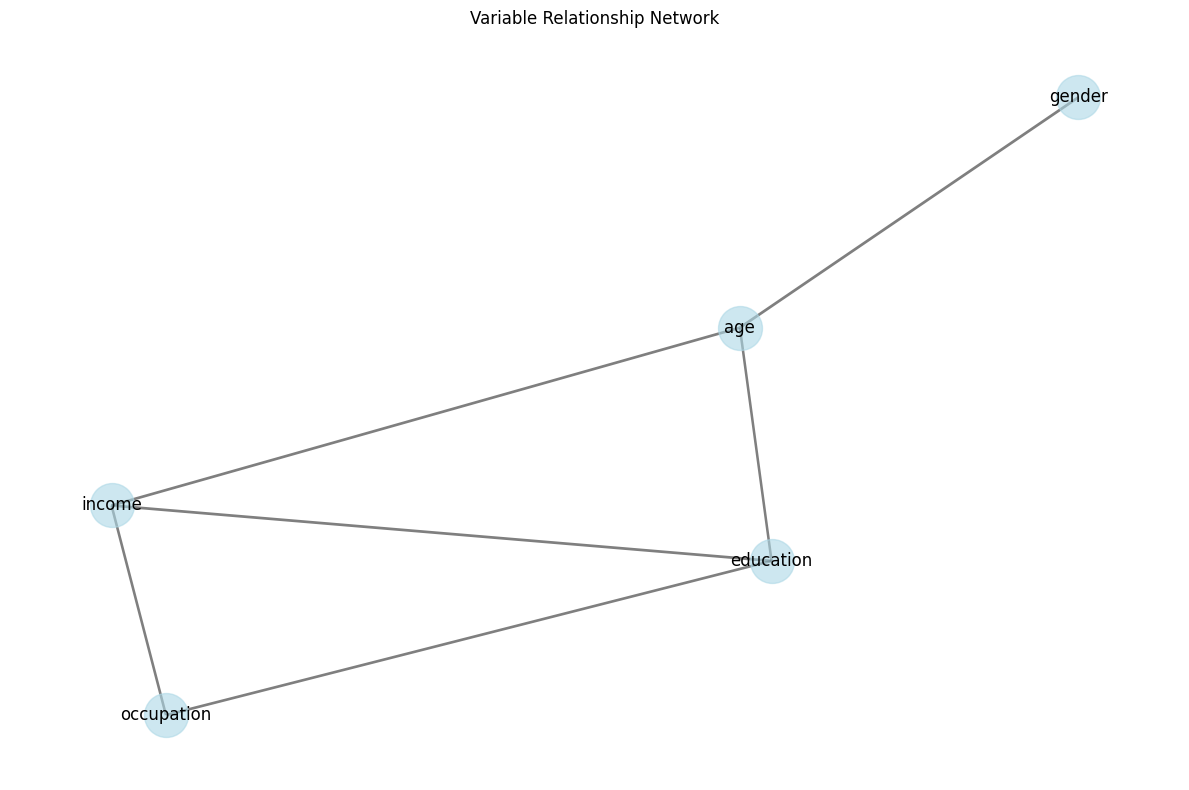


Variable Clusters:
--------------------------------------------------
Cluster 1: income, age, education, occupation, gender


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_variable_associations(df, p_threshold=0.05):
    """
    Analyze relationships between variables where one variable can have multiple associations
    
    Parameters:
    -----------
    df : pandas DataFrame
        Contains columns: var1, var2, chi2_pvalue, i1, i2
    p_threshold : float
        Threshold for statistical significance
    """
    
    def get_variable_network(var):
        """Get all associations for a specific variable"""
        as_var1 = df[df['var1'] == var]
        as_var2 = df[df['var2'] == var]
        
        # Combine both perspectives
        associations = pd.concat([
            as_var1[['var2', 'chi2_pvalue', 'i1', 'i2']].rename(columns={'var2': 'related_var'}),
            as_var2[['var1', 'chi2_pvalue', 'i1', 'i2']].rename(columns={'var1': 'related_var'})
        ])
        
        return associations
    
    # Get unique variables
    unique_vars = pd.unique(pd.concat([df['var1'], df['var2']]))
    
    # Analyze each variable's relationships
    variable_analysis = {}
    for var in unique_vars:
        associations = get_variable_network(var)
        
        variable_analysis[var] = {
            'total_associations': len(associations),
            'independent_associations': sum(associations['chi2_pvalue'] <= p_threshold),
            'dependent_associations': sum(associations['chi2_pvalue'] > p_threshold),
            'mean_importance': np.mean([associations['i1'].mean(), associations['i2'].mean()]),
            'associated_vars': associations['related_var'].tolist(),
            'independent_vars': associations[associations['chi2_pvalue'] <= p_threshold]['related_var'].tolist(),
            'dependent_vars': associations[associations['chi2_pvalue'] > p_threshold]['related_var'].tolist()
        }
    
    # Create summary DataFrame
    summary_df = pd.DataFrame(variable_analysis).T
    
    # Create network visualization
    G = nx.Graph()
    
    # Add edges with weights based on p-values
    for _, row in df.iterrows():
        G.add_edge(row['var1'], row['var2'], 
                  weight=1-row['chi2_pvalue'],  # Higher weight for lower p-value
                  p_value=row['chi2_pvalue'])
    
    return {
        'variable_analysis': variable_analysis,
        'summary': summary_df,
        'network': G,
        'detailed_pairs': analyze_pairs(df, p_threshold)
    }

def analyze_pairs(df, p_threshold):
    """Analyze variable pairs in detail"""
    # Create pair analysis
    pairs_df = df.copy()
    pairs_df['relationship'] = np.where(pairs_df['chi2_pvalue'] <= p_threshold,
                                      'Independent', 'Dependent')
    
    # Group by var1 to see its associations
    var1_groups = pairs_df.groupby('var1').agg({
        'var2': list,
        'chi2_pvalue': list,
        'relationship': list
    }).reset_index()
    
    return pairs_df

def plot_variable_network(G, title="Variable Relationship Network"):
    """Plot network of variable relationships"""
    plt.figure(figsize=(12, 8))
    
    # Position nodes using spring layout
    pos = nx.spring_layout(G)
    
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                          node_size=1000, alpha=0.6)
    
    # Draw edges with varying thickness based on weight
    edges = G.edges()
    weights = [G[u][v]['weight'] * 2 for u, v in edges]
    nx.draw_networkx_edges(G, pos, width=weights, alpha=0.5)
    
    # Add labels
    nx.draw_networkx_labels(G, pos)
    
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    
    return plt

# Example usage
if __name__ == "__main__":
    # Create sample data with multiple associations
    data = {
        'var1': ['age', 'age', 'income', 'income', 'education', 'education', 'gender'],
        'var2': ['income', 'education', 'education', 'occupation', 'occupation', 'age', 'age'],
        'chi2_pvalue': [0.03, 0.07, 0.02, 0.06, 0.04, 0.08, 0.01],
        'i1': [0.8, 0.6, 0.7, 0.5, 0.9, 0.4, 0.7],
        'i2': [0.7, 0.5, 0.6, 0.4, 0.8, 0.3, 0.6]
    }
    
    df = pd.DataFrame(data)
    results = analyze_variable_associations(df)
    
    # Print summary for each variable
    print("\nVariable Analysis Summary:")
    print("-" * 50)
    print(results['summary'])
    
    # Print detailed associations for each variable
    print("\nDetailed Variable Associations:")
    print("-" * 50)
    for var, analysis in results['variable_analysis'].items():
        print(f"\n{var}:")
        print(f"Total associations: {analysis['total_associations']}")
        print(f"Independent variables: {', '.join(analysis['independent_vars'])}")
        print(f"Dependent variables: {', '.join(analysis['dependent_vars'])}")
    
    # Plot network
    plot_variable_network(results['network'])
    plt.show()
    
    # Additional analysis: Variable clusters
    def find_variable_clusters(G):
        """Find clusters of related variables"""
        return list(nx.connected_components(G))
    
    clusters = find_variable_clusters(results['network'])
    print("\nVariable Clusters:")
    print("-" * 50)
    for i, cluster in enumerate(clusters, 1):
        print(f"Cluster {i}: {', '.join(cluster)}")

In [3]:
import pandas as pd
import numpy as np

def get_filtered_variables(df, p_threshold=0.05):
    """
    Get list of variables where:
    1. P-value > 0.05 (dependent variables)
    2. Select variable with higher importance between var1 and var2
    
    Parameters:
    -----------
    df : pandas DataFrame
        Contains columns: var1, var2, chi2_pvalue, i1, i2
    p_threshold : float, default=0.05
        P-value threshold
    
    Returns:
    --------
    DataFrame with filtered variables and their importance
    """
    
    # Filter for p-value > threshold
    dependent_vars = df[df['chi2_pvalue'] > p_threshold].copy()
    
    # Create columns for selected variables and their importance
    dependent_vars['selected_var'] = np.where(
        dependent_vars['i1'] > dependent_vars['i2'],
        dependent_vars['var1'],
        dependent_vars['var2']
    )
    
    dependent_vars['importance'] = np.maximum(
        dependent_vars['i1'],
        dependent_vars['i2']
    )
    
    # Create detailed results
    results = dependent_vars[[
        'var1', 'var2', 'chi2_pvalue', 'i1', 'i2', 
        'selected_var', 'importance'
    ]].sort_values('importance', ascending=False)
    
    # Add explanation column
    results['selection_reason'] = results.apply(
        lambda x: (
            f"Selected {x['selected_var']} (importance: {x['importance']:.3f}) over "
            f"{x['var2'] if x['selected_var'] == x['var1'] else x['var1']} "
            f"(importance: {x['i2'] if x['selected_var'] == x['var1'] else x['i1']:.3f})"
        ),
        axis=1
    )
    
    return results

# Example usage
if __name__ == "__main__":
    # Create sample data
    data = {
        'var1': ['age', 'income', 'education', 'occupation', 'gender', 'experience'],
        'var2': ['salary', 'experience', 'skill', 'industry', 'role', 'age'],
        'chi2_pvalue': [0.07, 0.08, 0.06, 0.09, 0.07, 0.08],  # all > 0.05
        'i1': [0.8, 0.6, 0.7, 0.5, 0.9, 0.4],
        'i2': [0.7, 0.8, 0.6, 0.7, 0.5, 0.6]
    }
    
    df = pd.DataFrame(data)
    
    # Get filtered results
    results = get_filtered_variables(df)
    
    # Print results
    print("\nFiltered Variables (p > 0.05, higher importance selected):")
    print("-" * 80)
    
    # Create summary table
    summary = pd.DataFrame({
        'Variable Pair': [f"{row['var1']} vs {row['var2']}" for _, row in results.iterrows()],
        'P-value': results['chi2_pvalue'].round(3),
        'Selected Variable': results['selected_var'],
        'Importance': results['importance'].round(3),
        'Reason': results['selection_reason']
    })
    
    print(summary.to_string(index=False))
    
    # Additional summary statistics
    print("\nSummary Statistics:")
    print("-" * 80)
    print(f"Total dependent pairs found: {len(results)}")
    
    # Group by selected variables
    selected_vars_summary = results.groupby('selected_var').agg({
        'importance': ['count', 'mean', 'max']
    }).round(3)
    
    print("\nSelected Variables Summary:")
    print("-" * 80)
    print(selected_vars_summary)
    
    # Create final list of unique selected variables
    final_vars = results.groupby('selected_var')['importance'].max().sort_values(ascending=False)
    
    print("\nFinal List of Selected Variables (Ordered by Importance):")
    print("-" * 80)
    for var, importance in final_vars.items():
        print(f"{var}: {importance:.3f}")
        
    # Optional: Export to Excel
    def export_results(results, filename="variable_selection_results.xlsx"):
        """Export results to Excel with multiple sheets"""
        with pd.ExcelWriter(filename) as writer:
            # Detailed results
            results.to_excel(writer, sheet_name='Detailed_Results', index=False)
            
            # Summary by selected variables
            selected_vars_summary.to_excel(writer, sheet_name='Variables_Summary')
            
            # Final list
            final_vars.to_frame('importance').to_excel(writer, sheet_name='Final_Variables')
            
        print(f"\nResults exported to {filename}")
    
    # Uncomment to export results
    # export_results(results)


Filtered Variables (p > 0.05, higher importance selected):
--------------------------------------------------------------------------------
         Variable Pair  P-value Selected Variable  Importance                                                                    Reason
        gender vs role     0.07            gender         0.9         Selected gender (importance: 0.900) over role (importance: 0.500)
         age vs salary     0.07               age         0.8          Selected age (importance: 0.800) over salary (importance: 0.700)
  income vs experience     0.08        experience         0.8   Selected experience (importance: 0.800) over income (importance: 0.600)
    education vs skill     0.06         education         0.7     Selected education (importance: 0.700) over skill (importance: 0.600)
occupation vs industry     0.09          industry         0.7 Selected industry (importance: 0.700) over occupation (importance: 0.500)
     experience vs age     0.08            

In [4]:
import pandas as pd
import numpy as np

def analyze_variable_selection(df, p_threshold=0.05):
    """
    Select variables based on:
    1. If p < 0.05: Select variable with higher importance between var1 and var2
    2. If p >= 0.05: Keep both variables
    
    Parameters:
    -----------
    df : pandas DataFrame
        Contains columns: var1, var2, chi2_pvalue, i1, i2
    p_threshold : float, default=0.05
        P-value threshold
    """
    
    def get_selected_vars(row):
        """Helper function to determine which variables to select"""
        if row['chi2_pvalue'] <= p_threshold:
            # For independent variables (p <= 0.05), select the one with higher importance
            if row['i1'] > row['i2']:
                return [row['var1']]
            else:
                return [row['var2']]
        else:
            # For dependent variables (p > 0.05), keep both
            return [row['var1'], row['var2']]
    
    # Create results DataFrame
    results = df.copy()
    
    # Add selection information
    results['selected_vars'] = results.apply(get_selected_vars, axis=1)
    results['selection_type'] = np.where(
        results['chi2_pvalue'] <= p_threshold,
        'Single (Independent)',
        'Both (Dependent)'
    )
    
    # Add explanation
    results['selection_reason'] = results.apply(
        lambda x: (
            f"Selected {x['var1' if x['i1'] > x['i2'] else 'var2']} "
            f"(importance: {max(x['i1'], x['i2']):.3f})"
            if x['chi2_pvalue'] <= p_threshold else
            f"Kept both (p > 0.05): {x['var1']} ({x['i1']:.3f}), {x['var2']} ({x['i2']:.3f})"
        ),
        axis=1
    )
    
    # Get final list of unique variables with their highest importance
    final_vars = {}
    
    for _, row in results.iterrows():
        for var in row['selected_vars']:
            importance = row['i1'] if var == row['var1'] else row['i2']
            if var not in final_vars or importance > final_vars[var]['importance']:
                final_vars[var] = {
                    'importance': importance,
                    'selection_type': row['selection_type'],
                    'p_value': row['chi2_pvalue']
                }
    
    return {
        'detailed_results': results,
        'final_variables': final_vars
    }

# Example usage
if __name__ == "__main__":
    # Create sample data
    data = {
        'var1': ['age', 'income', 'education', 'occupation', 'gender', 'experience'],
        'var2': ['salary', 'experience', 'skill', 'industry', 'role', 'age'],
        'chi2_pvalue': [0.03, 0.08, 0.02, 0.09, 0.04, 0.07],
        'i1': [0.8, 0.6, 0.7, 0.5, 0.9, 0.4],
        'i2': [0.7, 0.8, 0.6, 0.7, 0.5, 0.6]
    }
    
    df = pd.DataFrame(data)
    results = analyze_variable_selection(df)
    
    # Print detailed results
    print("\nDetailed Analysis:")
    print("-" * 100)
    detailed_summary = pd.DataFrame({
        'Variable Pair': [f"{row['var1']} vs {row['var2']}" for _, row in results['detailed_results'].iterrows()],
        'P-value': results['detailed_results']['chi2_pvalue'].round(3),
        'Selection Type': results['detailed_results']['selection_type'],
        'Selection Details': results['detailed_results']['selection_reason']
    })
    print(detailed_summary.to_string(index=False))
    
    # Print final variable list
    print("\nFinal Variable List:")
    print("-" * 100)
    final_vars_df = pd.DataFrame.from_dict(results['final_variables'], orient='index')
    final_vars_df = final_vars_df.sort_values('importance', ascending=False)
    
    print("\nSelected Variables (Sorted by Importance):")
    for var, info in final_vars_df.iterrows():
        print(f"{var}:")
        print(f"  Importance: {info['importance']:.3f}")
        print(f"  Selection Type: {info['selection_type']}")
        print(f"  P-value: {info['p_value']:.3f}")
        print()
    
    # Summary statistics
    print("\nSummary Statistics:")
    print("-" * 100)
    print(f"Total variables selected: {len(results['final_variables'])}")
    print(f"Independent selections: {sum(final_vars_df['selection_type'] == 'Single (Independent)')}")
    print(f"Dependent pairs: {sum(final_vars_df['selection_type'] == 'Both (Dependent)')}")
    
    # Optional: Export results to Excel
    def export_results(results, filename="variable_selection_analysis.xlsx"):
        """Export results to Excel with multiple sheets"""
        with pd.ExcelWriter(filename) as writer:
            # Detailed results
            results['detailed_results'].to_excel(writer, sheet_name='Detailed_Analysis', index=False)
            
            # Final variables
            pd.DataFrame.from_dict(results['final_variables'], orient='index')\
                .sort_values('importance', ascending=False)\
                .to_excel(writer, sheet_name='Final_Variables')
            
        print(f"\nResults exported to {filename}")
    
    # Uncomment to export results
    # export_results(results)


Detailed Analysis:
----------------------------------------------------------------------------------------------------
         Variable Pair  P-value       Selection Type                                          Selection Details
         age vs salary     0.03 Single (Independent)                           Selected age (importance: 0.800)
  income vs experience     0.08     Both (Dependent)   Kept both (p > 0.05): income (0.600), experience (0.800)
    education vs skill     0.02 Single (Independent)                     Selected education (importance: 0.700)
occupation vs industry     0.09     Both (Dependent) Kept both (p > 0.05): occupation (0.500), industry (0.700)
        gender vs role     0.04 Single (Independent)                        Selected gender (importance: 0.900)
     experience vs age     0.07     Both (Dependent)      Kept both (p > 0.05): experience (0.400), age (0.600)

Final Variable List:
-------------------------------------------------------------------------

In [5]:
import pandas as pd
import numpy as np

def analyze_variable_selection_with_dedup(df, p_threshold=0.05):
    """
    Select variables based on:
    1. If p > 0.05: Select variable with higher importance
    2. If p <= 0.05: Keep both variables
    3. Remove duplicates by keeping highest importance, ignoring p-values
    """
    
    def get_selected_vars(row):
        """Helper function to determine which variables to select"""
        if row['chi2_pvalue'] > p_threshold:
            # For dependent variables (p > 0.05), select the one with higher importance
            if row['i1'] > row['i2']:
                return [row['var1']]
            else:
                return [row['var2']]
        else:
            # For independent variables (p <= 0.05), keep both
            return [row['var1'], row['var2']]
    
    # Step 1: Initial variable selection
    results = df.copy()
    results['selected_vars'] = results.apply(get_selected_vars, axis=1)
    
    # Step 2: Collect all variables and their importances
    var_importances = []
    
    # From var1
    for _, row in results.iterrows():
        if row['var1'] in row['selected_vars']:
            var_importances.append({
                'variable': row['var1'],
                'importance': row['i1']
            })
    
    # From var2
    for _, row in results.iterrows():
        if row['var2'] in row['selected_vars']:
            var_importances.append({
                'variable': row['var2'],
                'importance': row['i2']
            })
    
    # Step 3: Create DataFrame of all variables and importances
    var_imp_df = pd.DataFrame(var_importances)
    
    # Step 4: Get highest importance for each variable
    final_vars = var_imp_df.groupby('variable')['importance'].max().reset_index()
    
    # Sort by importance
    final_vars = final_vars.sort_values('importance', ascending=False)
    
    # Add tracking information
    tracking_info = []
    for _, row in results.iterrows():
        pair_info = {
            'var1': row['var1'],
            'var2': row['var2'],
            'p_value': row['chi2_pvalue'],
            'i1': row['i1'],
            'i2': row['i2'],
            'selected': row['selected_vars'],
            'reason': (
                f"Kept both (p ≤ 0.05)" if row['chi2_pvalue'] <= p_threshold else
                f"Selected {row['var1'] if row['i1'] > row['i2'] else row['var2']} "
                f"(higher importance: {max(row['i1'], row['i2']):.3f})"
            )
        }
        tracking_info.append(pair_info)
    
    return {
        'final_variables': final_vars,
        'tracking_info': pd.DataFrame(tracking_info)
    }

# Example usage
if __name__ == "__main__":
    # Create sample data with multiple associations
    data = {
        'var1': ['age', 'age', 'income', 'experience', 'education', 'education', 'gender'],
        'var2': ['salary', 'education', 'experience', 'skill', 'skill', 'age', 'age'],
        'chi2_pvalue': [0.03, 0.07, 0.08, 0.02, 0.09, 0.04, 0.06],
        'i1': [0.8, 0.6, 0.7, 0.5, 0.9, 0.4, 0.7],
        'i2': [0.7, 0.5, 0.8, 0.6, 0.7, 0.3, 0.6]
    }
    
    df = pd.DataFrame(data)
    results = analyze_variable_selection_with_dedup(df)
    
    # Print final deduplicated list
    print("\nFinal Deduplicated Variable List (Sorted by Importance):")
    print("-" * 70)
    print(results['final_variables'].to_string(index=False))
    
    # Print tracking information
    print("\nVariable Selection Process:")
    print("-" * 70)
    tracking = results['tracking_info']
    for _, row in tracking.iterrows():
        print(f"\n{row['var1']} vs {row['var2']}:")
        print(f"  P-value: {row['p_value']:.3f}")
        print(f"  Importances: {row['var1']}: {row['i1']:.3f}, {row['var2']}: {row['i2']:.3f}")
        print(f"  Decision: {row['reason']}")
    
    # Create summary with variable appearances
    var_appearances = pd.concat([df['var1'], df['var2']]).value_counts().reset_index()
    var_appearances.columns = ['variable', 'appearances']
    
    # Merge with final variables
    summary = pd.merge(
        results['final_variables'],
        var_appearances,
        on='variable',
        how='left'
    )
    
    print("\nFinal Summary:")
    print("-" * 70)
    print(summary.to_string(index=False))
    
    # Export function
    def export_results(results, filename="variable_selection_final.xlsx"):
        """Export results to Excel with multiple sheets"""
        with pd.ExcelWriter(filename) as writer:
            # Final variables
            results['final_variables'].to_excel(
                writer,
                sheet_name='Final_Variables',
                index=False
            )
            
            # Selection process
            results['tracking_info'].to_excel(
                writer,
                sheet_name='Selection_Process',
                index=False
            )
            
            # Summary with appearances
            summary.to_excel(
                writer,
                sheet_name='Summary',
                index=False
            )
            
        print(f"\nResults exported to {filename}")
    
    # Uncomment to export results
    # export_results(results)


Final Deduplicated Variable List (Sorted by Importance):
----------------------------------------------------------------------
  variable  importance
 education         0.9
       age         0.8
experience         0.8
    gender         0.7
    salary         0.7
     skill         0.6

Variable Selection Process:
----------------------------------------------------------------------

age vs salary:
  P-value: 0.030
  Importances: age: 0.800, salary: 0.700
  Decision: Kept both (p ≤ 0.05)

age vs education:
  P-value: 0.070
  Importances: age: 0.600, education: 0.500
  Decision: Selected age (higher importance: 0.600)

income vs experience:
  P-value: 0.080
  Importances: income: 0.700, experience: 0.800
  Decision: Selected experience (higher importance: 0.800)

experience vs skill:
  P-value: 0.020
  Importances: experience: 0.500, skill: 0.600
  Decision: Kept both (p ≤ 0.05)

education vs skill:
  P-value: 0.090
  Importances: education: 0.900, skill: 0.700
  Decision: Selected 